In [ ]:
!pip install gradio

In [17]:
from fastai.vision.all import *
import gradio as gr
import torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import cv2
import numpy as np
import kagglehub
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
import shutil


In [18]:

path_str = kagglehub.dataset_download("msambare/fer2013")
path = Path(path_str)
train_path = path/'train'
valid_path = path/'test'

image_row, image_col = 48, 48
expression_classes = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]
expression_enum = {exp: idx for idx, exp in enumerate(expression_classes)}

Train set expression counts:
       surprise  fear  angry  neutral   sad  disgust  happy
train      3171  4097   3995     4965  4830      436   7215

Test set expression counts:
      surprise  fear  angry  neutral   sad  disgust  happy
test       831  1024    958     1233  1247      111   1774
Sample image for expression: surprise


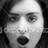

Sample image for expression: fear


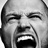

Sample image for expression: angry


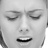

Sample image for expression: neutral


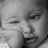

Sample image for expression: sad


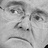

Sample image for expression: disgust


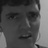

Sample image for expression: happy


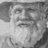

In [19]:


def count_exp(path_obj, set_):
    dict_ = {}
    for expression in os.listdir(path_obj):
        dir_ = path_obj / expression
        if os.path.isdir(dir_):
            dict_[expression] = len(os.listdir(dir_))
    df = pd.DataFrame(dict_, index=[set_])
    return df

train_count = count_exp(train_path, 'train')
test_count = count_exp(valid_path, 'test')
print("Train set expression counts:")
print(train_count)
print("\nTest set expression counts:")
print(test_count)

for expression in os.listdir(train_path):
    expression_dir = train_path / expression
    if os.path.isdir(expression_dir):
        images = get_image_files(expression_dir)
        if len(images) > 0:
            print(f"Sample image for expression: {expression}")
            display(Image.open(images[0]))

In [20]:
class ExpressionDataset(torch.utils.data.Dataset):
    def __init__(self, path_dir):
        self.samples = []
        for label in os.listdir(path_dir):
            folder = path_dir / label
            if os.path.isdir(folder):
                for img_path in get_image_files(folder):
                    self.samples.append((img_path, expression_enum[label]))
        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((48, 48)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("L")
        return self.transform(image), label

train_ds = ExpressionDataset(train_path)
test_ds = ExpressionDataset(valid_path)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=64)

In [21]:

def initialize_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

In [22]:

class CNNExpression(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 7)
        )

        self.apply(initialize_weights)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [23]:
model = CNNExpression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

CNNExpression(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=4608, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    

In [24]:
# Train Function
def train_model(model, train_dl, num_epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    loss_history = []
    acc_history = []

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            correct += (pred.argmax(1) == yb).sum().item()
            total += xb.size(0)

        scheduler.step()

        epoch_loss = total_loss / total
        epoch_acc = correct / total
        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)

        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.4f}")

    # Plot loss and accuracy
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs+1), loss_history, label='Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs+1), acc_history, label='Accuracy', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Epoch 1: Loss = 1.7384, Accuracy = 0.2954
Epoch 2: Loss = 1.5142, Accuracy = 0.4112
Epoch 3: Loss = 1.3855, Accuracy = 0.4666
Epoch 4: Loss = 1.3075, Accuracy = 0.5042
Epoch 5: Loss = 1.2522, Accuracy = 0.5258
Epoch 6: Loss = 1.2119, Accuracy = 0.5427
Epoch 7: Loss = 1.1795, Accuracy = 0.5536
Epoch 8: Loss = 1.1451, Accuracy = 0.5663
Epoch 9: Loss = 1.1202, Accuracy = 0.5798
Epoch 10: Loss = 1.0972, Accuracy = 0.5844
Epoch 11: Loss = 1.0833, Accuracy = 0.5911
Epoch 12: Loss = 1.0625, Accuracy = 0.5968
Epoch 13: Loss = 1.0504, Accuracy = 0.6045
Epoch 14: Loss = 1.0324, Accuracy = 0.6113
Epoch 15: Loss = 1.0174, Accuracy = 0.6199
Epoch 16: Loss = 0.9571, Accuracy = 0.6413
Epoch 17: Loss = 0.9337, Accuracy = 0.6491
Epoch 18: Loss = 0.9177, Accuracy = 0.6531
Epoch 19: Loss = 0.9125, Accuracy = 0.6566
Epoch 20: Loss = 0.9082, Accuracy = 0.6581
Epoch 21: Loss = 0.9025, Accuracy = 0.6576
Epoch 22: Loss = 0.8886, Accuracy = 0.6634
Epoch 23: Loss = 0.8890, Accuracy = 0.6637
Epoch 24: Loss = 0.8

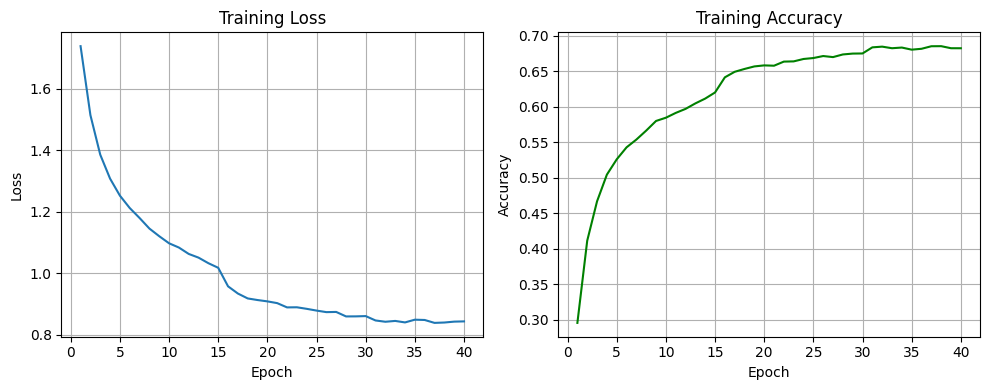

In [25]:
train_model(model, train_dl, num_epochs=40, lr=1e-3)


In [26]:

torch.save(model.state_dict(), "cnn_expression_model-v2.pth")
import pickle
with open("cnn_expression_model-v2.pkl", "wb") as f:
    pickle.dump(model, f)

In [27]:
files.download("cnn_expression_model-v2.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install face_recognition

In [29]:

import face_recognition

def predict_expression(image):

    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    face_locations = face_recognition.face_locations(rgb_image)

    if len(face_locations) == 0:
        return image, "No human face detected."

    top, right, bottom, left = face_locations[0]

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    face_img = gray_image[top:bottom, left:right]

    face_img = cv2.resize(face_img, (48, 48))
    image_tensor = transforms.ToTensor()(face_img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(image_tensor)
        pred = torch.argmax(logits, dim=1).item()
    label = expression_classes[pred]

    image_with_box = image.copy()
    cv2.rectangle(image_with_box, (left, top), (right, bottom), (0,255,0), 2)

    return image_with_box, f"Predicted Expression: {label}"


sample_images = []
for i in range(6):
    img_path, _ = test_ds.samples[i+1]
    sample_images.append(str(img_path))

In [30]:

demo = gr.Interface(
    fn=predict_expression,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=[gr.Image(type="numpy", label="Processed Image"), gr.Textbox(label="Prediction")],
    examples=sample_images,
    title="Facial Expression Recognition",
    description="Upload people to find out their expressions. Images aside that will be labeled as no human, therefore will give the notification 'No human face detected.'. "
)
demo.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5026366bd1867946e3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
